# Mega Case Study

## Part 1 - SOM

### Importing the libraries

In [4]:
!pip install minisom

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Importing the dataset

In [6]:
dataset = pd.read_csv('Credit_Card_Applications.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

### Feature Scaling

In [7]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
X = sc.fit_transform(X)

### Training the SOM

In [8]:
from minisom import MiniSom
som = MiniSom(x=10, y=10, input_len= 15, sigma= 1.0, learning_rate = 0.5)
som.random_weights_init(X)
som.train_random(data = X, num_iteration = 100)

### Visualizing the results

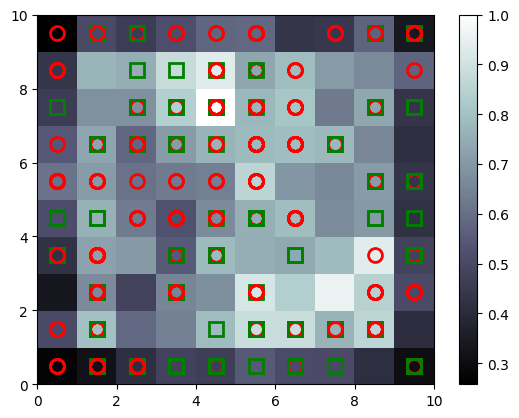

In [9]:
from pylab import bone, pcolor, colorbar, plot, show
bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors = ['r', 'g']
for i, x in enumerate(X):
    w = som.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10,
         markeredgewidth = 2)
show()

### Finding the frauds

In [10]:
mappings = som.win_map(X)
frauds = np.concatenate((mappings[(6,8)], mappings[(5,1)]), axis = 0)
frauds = sc.inverse_transform(frauds)

### Printing the fraudulent clients

In [11]:
print('Fraud Customer IDs')
for i in frauds[:, 0]:
  print(int(i))

Fraud Customer IDs
15731586
15575605
15644453
15768600
15757467
15815443
15748432
15708714
15771856
15808023
15795079
15808386
15786539
15773776
15778345
15791769
15776494


## Part 2 - Going from Unsupervised to Supervised Deep Learning

### Creating the Matrix of Features

In [12]:
customers = dataset.iloc[:, 1:].values

### Creating the Dependent Variable

In [13]:
is_fraud = np.zeros(len(dataset))
for i in range(len(dataset)):
  if dataset.iloc[i,0] in frauds:
    is_fraud[i] = 1

## Part 3 - ANN

### Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
customers = sc.fit_transform(customers)

### Building the ANN

In [15]:
import tensorflow as tf
tf.__version__

'2.18.0'

In [16]:
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=2, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

### Training the ANN

In [17]:
ann.fit(customers, is_fraud, batch_size = 1, epochs = 10)

Epoch 1/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - accuracy: 0.9831 - loss: 0.4145
Epoch 2/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 800us/step - accuracy: 0.9749 - loss: 0.2182
Epoch 3/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.9693 - loss: 0.1455
Epoch 4/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step - accuracy: 0.9711 - loss: 0.1062
Epoch 5/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 862us/step - accuracy: 0.9756 - loss: 0.0783
Epoch 6/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - accuracy: 0.9741 - loss: 0.0838
Epoch 7/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step - accuracy: 0.9759 - loss: 0.0717
Epoch 8/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - accuracy: 0.9756 - loss: 0.0638
Epoch 9/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step - accuracy: 0.9696 - loss: 0.0764
Epoch 10/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - accuracy: 0.9844 - loss: 0.0509


### Predicting the test set results

In [18]:
y_pred = ann.predict(customers)
y_pred = np.concatenate((dataset.iloc[:, 0:1].values, y_pred), axis = 1)
y_pred = y_pred[y_pred[:, 1].argsort()]

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [19]:
print(y_pred)

[[1.56214230e+07 2.44403822e-08]
 [1.56325030e+07 4.64521179e-07]
 [1.57654870e+07 2.14942861e-06]
 ...
 [1.57938960e+07 2.53774613e-01]
 [1.57764940e+07 2.53774613e-01]
 [1.57574670e+07 2.53774613e-01]]
